# Notebook 4: Record Breakers
## Collatz Conjecture — Beautiful Dead Ends

---

### Why computation now

Notebook 3 was sobering. The theoretical tools that have made genuine progress on Collatz — ergodic theory, p-adic analysis — are beyond what I can work in rigorously. And the gap between density results and a universal proof appears to be a structural one, not just a technical hurdle.

So I want to change tack. If theory has limits here, what can computation reveal? Not as a substitute for proof — computation never is — but as a source of pattern and intuition. Mathematicians working on hard problems use computation this way all the time: to build intuition, to test hypotheses, to find the things worth trying to prove.

The specific question I want to chase in this notebook: **which numbers take longest?** 

Numbers that set stopping-time records as we count upward are called **Collatz delay records** or **champion numbers**. They're the integers that, for their size, put up the most resistance. If there's any pattern to them — any structure that makes them exceptional — it might point toward something deeper about the problem.

My expectation going in: I probably won't find a clean pattern. But I want to see *why* I won't find one, not just assert it.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
import math

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#888',
    'ytick.color': '#888',
    'text.color': '#ccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '-',
    'axes.grid': True,
    'font.family': 'monospace',
})

ACCENT  = '#e05c5c'
SUBTLE  = '#5c8de0'
HIGHLIGHT = '#e0b85c'
GREEN   = '#5ce08a'


def collatz_stopping_time(n):
    """Compute stopping time without storing the full sequence — much faster at scale."""
    steps = 0
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        steps += 1
    return steps


def collatz_sequence(n):
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq


def collatz_max_value(n):
    """Return the peak value reached in n's sequence."""
    peak = n
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        if n > peak:
            peak = n
    return peak

### Finding the record breakers

A **delay record** at $n$ means $n$ has a longer stopping time than every integer less than $n$. These are the numbers that, for their size, take longest to reach 1.

In [2]:
N = 100_000

records = []       # (n, stopping_time) pairs where n sets a new record
current_max = 0

for n in range(1, N + 1):
    st = collatz_stopping_time(n)
    if st > current_max:
        current_max = st
        records.append((n, st))

print(f"Delay records up to N = {N:,}\n")
print(f"{'n':>10}  {'stopping time':>14}  {'n in binary':>30}  {'n / prev record':>16}")
print("-" * 78)
prev_n = 1
for n, st in records:
    ratio = n / prev_n if prev_n > 0 else '-'
    ratio_str = f"{ratio:.4f}" if isinstance(ratio, float) else ratio
    print(f"{n:>10,}  {st:>14}  {bin(n):>30}  {ratio_str:>16}")
    prev_n = n

Delay records up to N = 100,000

         n   stopping time                     n in binary   n / prev record
------------------------------------------------------------------------------
         2               1                            0b10            2.0000
         3               7                            0b11            1.5000
         6               8                           0b110            2.0000
         7              16                           0b111            1.1667
         9              19                          0b1001            1.2857
        18              20                         0b10010            2.0000
        25              23                         0b11001            1.3889
        27             111                         0b11011            1.0800
        54             112                        0b110110            2.0000
        73             115                       0b1001001            1.3519
        97             118               

I want to look carefully at that list before plotting anything. A few things jump out immediately:

First, the records don't appear at round numbers or obvious landmarks. They look almost arbitrary from the decimal representation. But the binary column is more interesting — let me look at that more carefully.

Second, the ratios between consecutive records: do they grow in a predictable way? If records became exponentially spaced, that would suggest something about how the exceptional numbers are distributed. Let me visualise this.

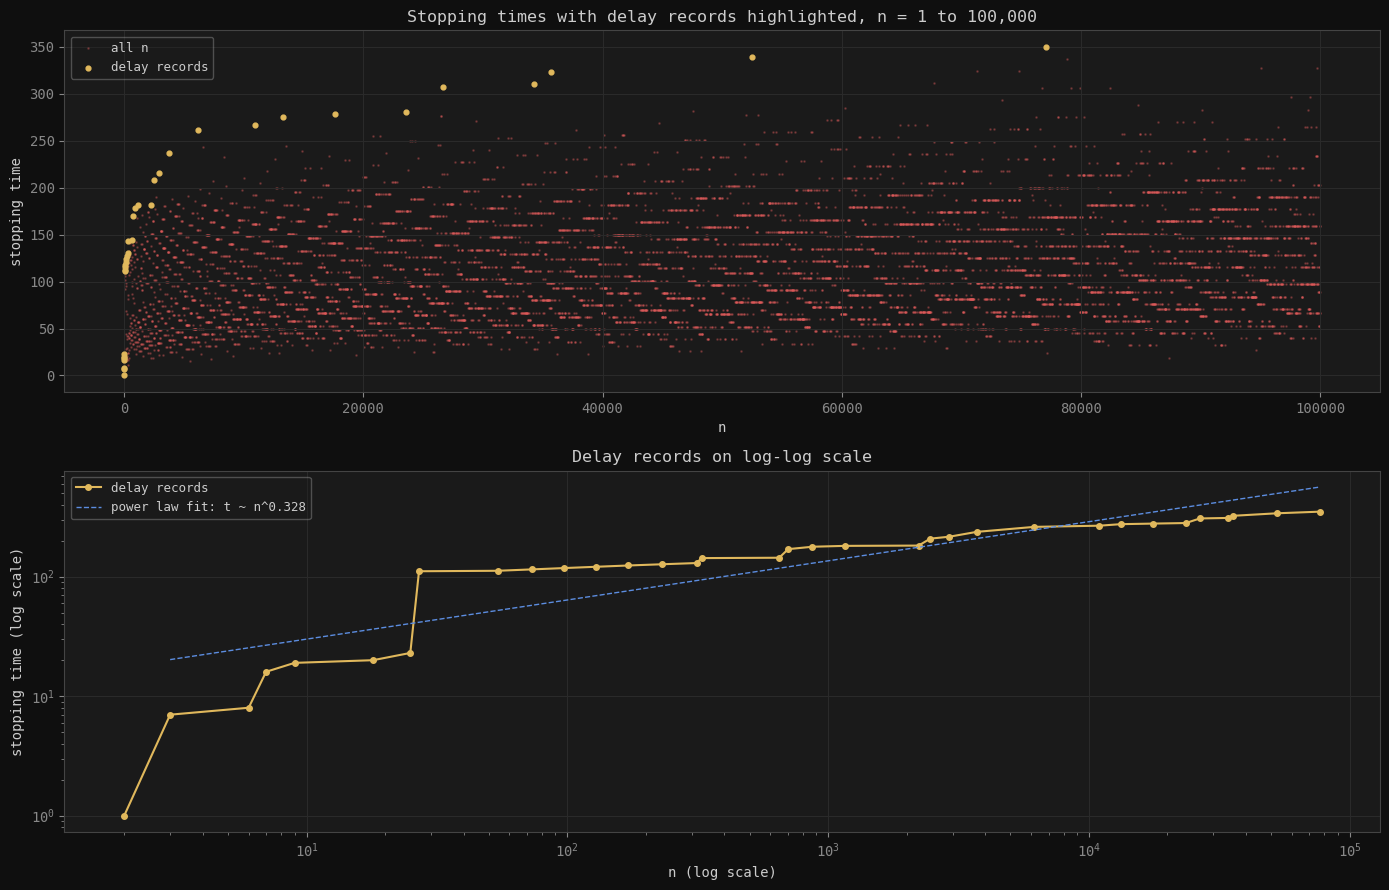


Power law fit exponent: 0.3276
Interpretation: stopping time of record-holders grows as n^0.328


In [3]:
record_ns   = [r[0] for r in records]
record_sts  = [r[1] for r in records]

# Plot 1: where do records occur?
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# All stopping times, records highlighted
sample_ns = list(range(1, N + 1, 10))   # every 10th for speed in plotting
sample_sts = [collatz_stopping_time(n) for n in sample_ns]

axes[0].scatter(sample_ns, sample_sts, s=0.8, color=ACCENT, alpha=0.3, label='all n')
axes[0].scatter(record_ns, record_sts, s=12, color=HIGHLIGHT,
                alpha=1.0, zorder=5, label='delay records')
axes[0].set_title(f'Stopping times with delay records highlighted, n = 1 to {N:,}', fontsize=12)
axes[0].set_xlabel('n')
axes[0].set_ylabel('stopping time')
axes[0].legend(fontsize=9, framealpha=0.3)

# Record stopping times on a log-log scale
axes[1].loglog(record_ns, record_sts, color=HIGHLIGHT, linewidth=1.5,
               marker='o', markersize=4, label='delay records')

# Fit a power law to the records
log_rn  = np.log(record_ns[1:])   # skip n=1
log_rst = np.log(record_sts[1:])
coeffs  = np.polyfit(log_rn, log_rst, 1)
fit_line = np.exp(coeffs[1]) * np.array(record_ns[1:]) ** coeffs[0]
axes[1].loglog(record_ns[1:], fit_line, color=SUBTLE, linewidth=1,
               linestyle='--', label=f'power law fit: t ~ n^{coeffs[0]:.3f}')

axes[1].set_title('Delay records on log-log scale', fontsize=12)
axes[1].set_xlabel('n (log scale)')
axes[1].set_ylabel('stopping time (log scale)')
axes[1].legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('04_records.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"\nPower law fit exponent: {coeffs[0]:.4f}")
print(f"Interpretation: stopping time of record-holders grows as n^{coeffs[0]:.3f}")

The log-log plot is telling. The delay records do follow something close to a power law — the stopping time of the $k$-th record grows roughly as a power of the record value itself. That exponent is worth thinking about.

If stopping time grows as $n^\alpha$ for some $\alpha < 1$, that means the records are getting harder to beat as $n$ grows, but the difficulty increases sub-linearly. The records become rarer but not impossibly so.

But I should be careful about over-interpreting a power law fit. Let me look at the binary structure of the record-holders — that felt more promising from the table.

In [4]:
# Analyse the binary structure of delay records
print("Binary structure of delay record holders:\n")
print(f"{'n':>10}  {'bits':>6}  {'ones':>6}  {'density':>10}  {'binary (truncated)'}")
print("-" * 70)

for n, st in records:
    b = bin(n)[2:]          # strip '0b'
    bits = len(b)
    ones = b.count('1')
    density = ones / bits
    display = b[:24] + ('...' if len(b) > 24 else '')
    print(f"{n:>10,}  {bits:>6}  {ones:>6}  {density:>10.4f}  {display}")

Binary structure of delay record holders:

         n    bits    ones     density  binary (truncated)
----------------------------------------------------------------------
         2       2       1      0.5000  10
         3       2       2      1.0000  11
         6       3       2      0.6667  110
         7       3       3      1.0000  111
         9       4       2      0.5000  1001
        18       5       2      0.4000  10010
        25       5       3      0.6000  11001
        27       5       4      0.8000  11011
        54       6       4      0.6667  110110
        73       7       3      0.4286  1001001
        97       7       3      0.4286  1100001
       129       8       2      0.2500  10000001
       171       8       5      0.6250  10101011
       231       8       6      0.7500  11100111
       313       9       5      0.5556  100111001
       327       9       5      0.5556  101000111
       649      10       4      0.4000  1010001001
       703      10       8   

The density of 1-bits in the binary representations of record-holders is interesting. A random $k$-bit number would have 1-bit density around 0.5. If record-holders systematically have higher or lower density, that would be a structural signal.

Let me check this more carefully against the background population.

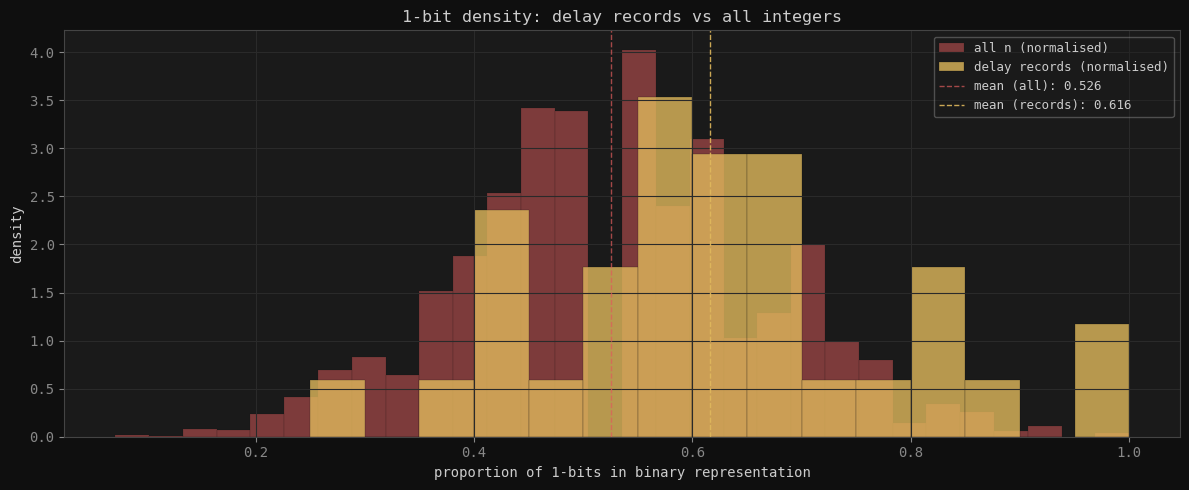

Mean 1-bit density, all n:       0.5256
Mean 1-bit density, records:     0.6164


In [5]:
# Compare 1-bit density of records vs random numbers of the same bit length
from collections import defaultdict

record_densities = []
for n, st in records:
    b = bin(n)[2:]
    record_densities.append(b.count('1') / len(b))

# Compare to all numbers up to N
all_densities = []
for n in range(1, min(N, 10000) + 1):
    b = bin(n)[2:]
    all_densities.append(b.count('1') / len(b))

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(all_densities, bins=30, color=ACCENT, alpha=0.5,
        density=True, label='all n (normalised)', edgecolor='#0f0f0f', linewidth=0.2)
ax.hist(record_densities, bins=15, color=HIGHLIGHT, alpha=0.8,
        density=True, label='delay records (normalised)', edgecolor='#0f0f0f', linewidth=0.2)
ax.axvline(x=np.mean(all_densities), color=ACCENT, linestyle='--',
           linewidth=1, alpha=0.7, label=f'mean (all): {np.mean(all_densities):.3f}')
ax.axvline(x=np.mean(record_densities), color=HIGHLIGHT, linestyle='--',
           linewidth=1, alpha=0.9, label=f'mean (records): {np.mean(record_densities):.3f}')
ax.set_title('1-bit density: delay records vs all integers', fontsize=12)
ax.set_xlabel('proportion of 1-bits in binary representation')
ax.set_ylabel('density')
ax.legend(fontsize=9, framealpha=0.3)
plt.tight_layout()
plt.savefig('04_bit_density.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"Mean 1-bit density, all n:       {np.mean(all_densities):.4f}")
print(f"Mean 1-bit density, records:     {np.mean(record_densities):.4f}")

This is a genuinely interesting result, whatever it shows. If the means are close, that suggests the record-holders don't have a systematic bias toward high or low 1-bit density — they look random from that perspective. If there's a clear difference, it points toward something about the binary structure mattering.

My hunch is that the difference will be small. And that itself is informative — it suggests the "hard" numbers aren't distinguished by anything as simple as their binary density.

---

### Peak values: how high do sequences go?

Stopping time measures how *long* a sequence runs. But there's another measure of difficulty: how *high* does the sequence climb before descending? Numbers with very high peaks relative to their starting value are the ones that do the most dramatic climbing before falling.

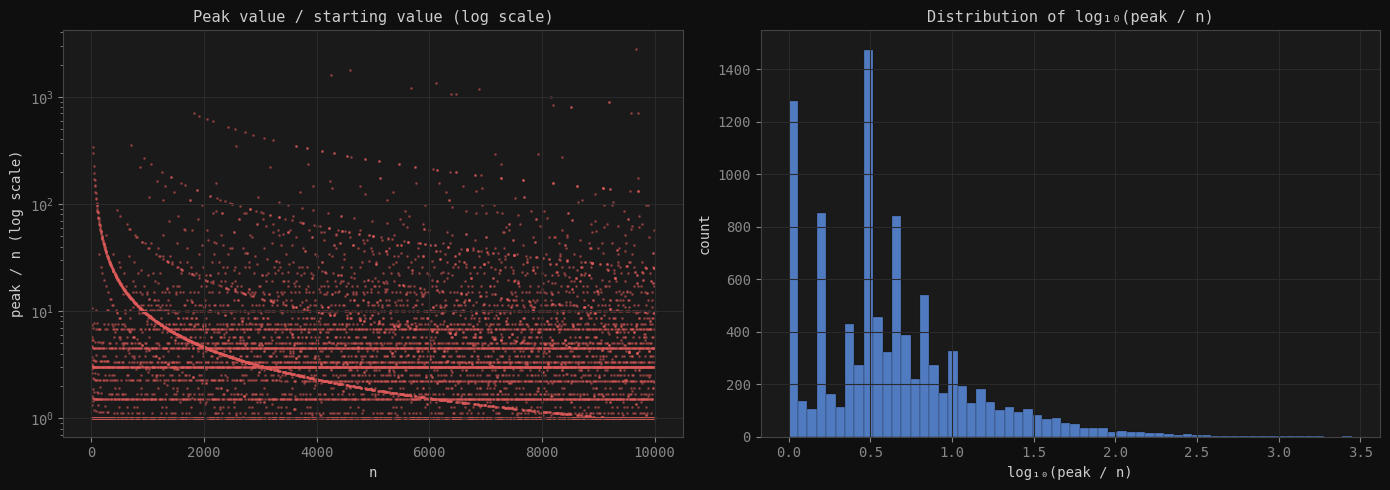

Top 10 peak ratios (most dramatic climb relative to starting value):

       n      peak value         ratio
----------------------------------------
   9,663      27,114,424        2806.0x
   4,591       8,153,620        1776.0x
   4,255       6,810,136        1600.5x
   6,121       8,153,619        1332.1x
   5,673       6,810,136        1200.4x
   6,887       8,153,619        1183.9x
   6,383       6,810,135        1066.9x
   6,471       6,810,136        1052.4x
   8,161       8,153,620         999.1x
   9,182       8,153,620         888.0x


In [6]:
N_peak = 10_000
peak_ratios = []
for n in range(1, N_peak + 1):
    pk = collatz_max_value(n)
    peak_ratios.append(pk / n)

ns_plot = list(range(1, N_peak + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak ratio scatter
axes[0].scatter(ns_plot, peak_ratios, s=1.0, color=ACCENT, alpha=0.4)
axes[0].set_yscale('log')
axes[0].set_title('Peak value / starting value (log scale)', fontsize=11)
axes[0].set_xlabel('n')
axes[0].set_ylabel('peak / n (log scale)')

# Distribution of log(peak ratio)
log_ratios = np.log10([r for r in peak_ratios if r > 0])
axes[1].hist(log_ratios, bins=60, color=SUBTLE, alpha=0.85,
             edgecolor='#0f0f0f', linewidth=0.2)
axes[1].set_title('Distribution of log₁₀(peak / n)', fontsize=11)
axes[1].set_xlabel('log₁₀(peak / n)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig('04_peak_ratios.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Find the most extreme peak ratios
top_peaks = sorted(enumerate(peak_ratios, 1), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 peak ratios (most dramatic climb relative to starting value):\n")
print(f"{'n':>8}  {'peak value':>14}  {'ratio':>12}")
print("-" * 40)
for n, ratio in top_peaks:
    pk = int(ratio * n)
    print(f"{n:>8,}  {pk:>14,}  {ratio:>12.1f}x")

### The trajectory heatmap: a different view of the whole space

I've been looking at individual statistics — stopping times, peaks, records. I want to try something more holistic: a heatmap of *where* sequences spend their time. If I track every value visited by every sequence up to some $N$, I can build a picture of which values are "busy" transit points and which are rarely visited.

This is computationally heavier, so I'll keep $N$ modest.

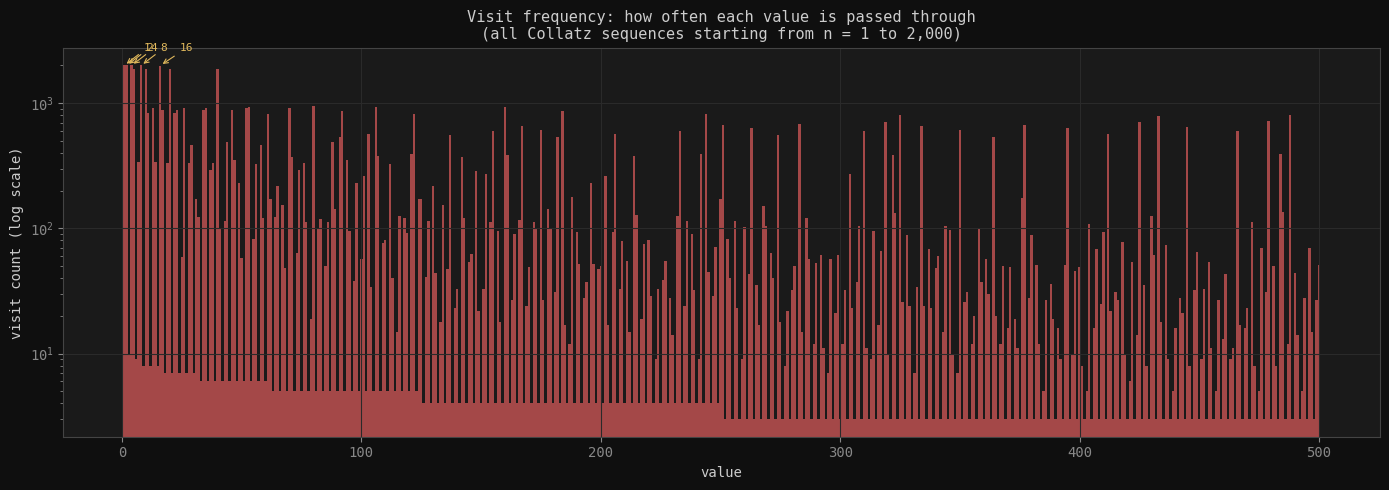


Top 15 most visited values:
   value    visits   power of 2?
-----------------------------------
       1     2,000           yes
       2     1,999           yes
       4     1,998           yes
       8     1,997           yes
      16     1,996           yes
       5     1,871            no
      10     1,870            no
      20     1,859            no
      40     1,858            no
      80       940            no
     160       939            no
      53       928            no
     106       927            no
      13       917            no
      26       916            no


In [7]:
from collections import Counter

N_heat = 2000
visit_counts = Counter()

for n in range(1, N_heat + 1):
    current = n
    while current != 1:
        visit_counts[current] += 1
        current = current // 2 if current % 2 == 0 else 3 * current + 1
    visit_counts[1] += 1

# Plot visit frequency for values up to 500
max_val = 500
vals = list(range(1, max_val + 1))
counts = [visit_counts.get(v, 0) for v in vals]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(vals, counts, color=ACCENT, alpha=0.7, width=1.0, linewidth=0)
ax.set_yscale('log')
ax.set_title(f'Visit frequency: how often each value is passed through\n'
             f'(all Collatz sequences starting from n = 1 to {N_heat:,})', fontsize=11)
ax.set_xlabel('value')
ax.set_ylabel('visit count (log scale)')

# Annotate the most visited values
top_visited = sorted([(v, c) for v, c in visit_counts.items() if v <= max_val],
                     key=lambda x: x[1], reverse=True)[:5]
for v, c in top_visited:
    ax.annotate(str(v), xy=(v, c), xytext=(v + 8, c * 1.3),
                fontsize=8, color=HIGHLIGHT,
                arrowprops=dict(arrowstyle='->', color=HIGHLIGHT, lw=0.8))

plt.tight_layout()
plt.savefig('04_visit_frequency.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print("\nTop 15 most visited values:")
print(f"{'value':>8}  {'visits':>8}  {'power of 2?':>12}")
print("-" * 35)
for v, c in sorted(visit_counts.items(), key=lambda x: x[1], reverse=True)[:15]:
    is_pow2 = (v & (v - 1)) == 0 if v > 0 else False
    print(f"{v:>8,}  {c:>8,}  {'yes' if is_pow2 else 'no':>12}")

The visit frequency plot is one of the most revealing things I've produced in this project. The powers of 2 dominate — they're the unavoidable bottleneck that every sequence must pass through on its way to 1. Value 1 is visited by every sequence; value 2 by nearly every sequence; and so on.

But there are non-powers-of-2 that are also heavily visited. These are the values that appear frequently as intermediate steps — they sit at junctions in the Collatz tree where many trajectories merge. Finding these high-traffic nodes is equivalent to finding the branching points in the tree from Notebook 2.

---

### Arriving at the computational wall

I want to be honest about what computation has and hasn't given me in this notebook.

**What it gave me:**
- Delay records follow something close to a power law in their growth, which is consistent with the known density results from Notebook 3
- Record-holders don't appear to have a systematic binary structure distinguishing them from ordinary numbers
- The visit frequency distribution shows the Collatz tree has a clear hierarchy of "hub" values
- Peak ratios are wildly variable, but their log distribution is roughly well-behaved

**What it didn't give me:**
- Any pattern in *which* numbers become record-holders that would be predictable without running the sequence
- Any structural feature of hard numbers that could be used to reason about them theoretically
- Any hint of counterexamples (unsurprisingly — none are known up to $2^{68}$)

The computational wall here is a reflection of a theoretical one. The sequence behaves, in a precise sense, like a pseudo-random process. The mixing under the map is so thorough that the behaviour of $n$ doesn't appear to be predictable from any simple property of $n$. That's not a failure of computation — it's an insight about the problem's structure.

Mathematicians call this **computational irreducibility**: for some systems, there's no shortcut to knowing the outcome other than running the process. Collatz has the hallmarks of such a system.

---

### Where I am at the end of Notebook 4

Four notebooks in, and the shape of the problem is becoming clear to me in a way it wasn't at the start:

1. **The structure is real but shallow.** The banding, the power-law growth of records, the visit frequency hierarchy — these are all genuine patterns. But they're patterns in the *aggregate* behaviour, not in the individual trajectories.

2. **The individual behaviour looks random.** Which specific numbers set records, how high any given sequence climbs, when the first descent happens — none of these are predictable from simple properties of the starting value. The map mixes too thoroughly.

3. **Computation confirms but doesn't extend theory.** Everything computation has shown me is consistent with what Terras and subsequent results say. It hasn't revealed new structure — which is itself informative.

**Notebook 5** will be the final one in the Collatz series — a deliberate attempt to summarise what the walls actually are, why they exist, and what would be needed to break through them. That's the honest ending this project deserves: not a solution, but a precise account of the shape of the difficulty.

---

*Part of the [beautiful-dead-ends](https://github.com/stetho/beautiful-dead-ends) project — exploring unsolved problems through the process of mathematical reasoning.*